<H1>Customer Segmentation Using Clustering</H1>
______________________________________________________________________________________________________


Group customers into meaningful segments using purchasing behaviour such as spending, purchase frequency, and recency. Apply an unsupervised learning technique such as K-Means, visualize the clusters, and explain how a business could use the segments.

| Customer Group | Behavior                       |
| -------------- | ------------------------------ |
| Cluster 0      | Recent and frequent buyers     |
| Cluster 1      | Inactive/old customers         |
| Cluster 2      | High-spending customers        |
| Cluster 3      | Low-value occasional customers |


Important: The numbers 0, 1, 2, 3 don't automatically mean those names. You interpret each cluster using the cluster statistics.

In [1]:
# ALL THE LIBARY OF THE CODE 
import pandas as pd 
import numpy as np 
import matplotlib as plt
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

| Library      | Purpose                |
| ------------ | ---------------------- |
| `pandas`     | Data handling          |
| `numpy`      | Numerical calculations |
| `matplotlib` | Graphs                 |
| `sklearn`    | Machine learning       |
| `KMeans`     | Clustering algorithm   |


In [2]:
# CSV FILE PATH AND LOAD THE DATA OF CSV ON COMPUTER AND THROUGHT PANADAS
df = pd.read_csv(r"C:\Users\surya\OneDrive\Desktop\meachin learning\data\online_retail.csv")

In [3]:
# IOT SHOW THE HEAD OF THE CSV FILE 
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


Why?

To understand:

       what columns exist

       what the data looks like

       whether it loaded correctl

In [4]:
#Remove unnecessary columns
df.drop(["StockCode","Description","Country"],axis=1)

,InvoiceNo,Quantity,InvoiceDate,UnitPrice,CustomerID
0,536365,6,2010-12-01 08:26:00,2.55,17850.0
1,536365,6,2010-12-01 08:26:00,3.39,17850.0
2,536365,8,2010-12-01 08:26:00,2.75,17850.0
3,536365,6,2010-12-01 08:26:00,3.39,17850.0
4,536365,6,2010-12-01 08:26:00,3.39,17850.0
...,...,...,...,...,...
541904,581587,12,2011-12-09 12:50:00,0.85,12680.0
541905,581587,6,2011-12-09 12:50:00,2.10,12680.0
541906,581587,4,2011-12-09 12:50:00,4.15,12680.0
541907,581587,4,2011-12-09 12:50:00,4.15,12680.0


In [5]:
#Remove customers without CustomerID
df = df.dropna(subset=["CustomerID"])

df = df[df["Quantity"] > 0]

df = df[df["UnitPrice"] > 0]

df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

In [6]:
df.shape

(397884, 9)

In [7]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [8]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df["InvoiceDate"].dtype

dtype('<M8[us]')

In [9]:
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

reference_date

Timestamp('2011-12-10 12:50:00')

In [10]:
rfm = df.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (reference_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalAmount", "sum")
)

In [11]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [12]:
rfm.shape

(4338, 3)

In [13]:
total_quantity = df.groupby("CustomerID")["Quantity"].sum()

In [14]:
unique_products = df.groupby("CustomerID")["StockCode"].nunique()

In [15]:
rfm["AvgOrderValue"] = rfm["Monetary"] / rfm["Frequency"]

In [16]:
rfm["TotalQuantity"] = total_quantity
rfm["UniqueProducts"] = unique_products

In [17]:
rfm.head()

,Recency,Frequency,Monetary,AvgOrderValue,TotalQuantity,UniqueProducts
CustomerID,,,,,,
12346.0,326,1,77183.60,77183.600000,74215,1
12347.0,2,7,4310.00,615.714286,2458,103
12348.0,75,4,1797.24,449.310000,2341,22
12349.0,19,1,1757.55,1757.550000,631,73
12350.0,310,1,334.40,334.400000,197,17


In [18]:
rfm.shape

(4338, 6)

In [19]:
rfm.describe()

,Recency,Frequency,Monetary,AvgOrderValue,TotalQuantity,UniqueProducts
count,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460,419.166289,1191.289073,61.501153
std,100.014169,7.697998,8989.230441,1796.537944,5046.081546,85.366768
min,1.000000,1.000000,3.750000,3.450000,1.000000,1.000000
25%,18.000000,1.000000,307.415000,178.625000,160.000000,16.000000
50%,51.000000,2.000000,674.485000,293.900000,379.000000,35.000000
75%,142.000000,5.000000,1661.740000,430.113750,992.750000,77.000000
max,374.000000,209.000000,280206.020000,84236.250000,196915.000000,1787.000000


In [20]:
rfm.isnull().sum()

Recency           0
Frequency         0
Monetary          0
AvgOrderValue     0
TotalQuantity     0
UniqueProducts    0
dtype: int64

In [21]:
np.isinf(rfm).sum()

Recency           0
Frequency         0
Monetary          0
AvgOrderValue     0
TotalQuantity     0
UniqueProducts    0
dtype: int64

In [22]:
rfm_log = np.log1p(rfm)

In [23]:
rfm_log.describe()

,Recency,Frequency,Monetary,AvgOrderValue,TotalQuantity,UniqueProducts
count,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000
mean,3.830734,1.345582,6.593627,5.651085,5.986220,3.551564
std,1.340261,0.683104,1.257578,0.744803,1.370079,1.131560
min,0.693147,0.693147,1.558145,1.492904,0.693147,0.693147
25%,2.944439,0.693147,5.731446,5.190871,5.081404,2.833213
50%,3.951244,1.098612,6.515431,5.686636,5.940171,3.583519
75%,4.962845,1.791759,7.416222,6.066372,6.901486,4.356709
max,5.926926,5.347108,12.543284,11.341393,12.190533,7.488853


In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_log)

rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=rfm.columns,
    index=rfm.index
)

In [25]:
rfm

,Recency,Frequency,Monetary,AvgOrderValue,TotalQuantity,UniqueProducts
CustomerID,,,,,,
12346.0,326,1,77183.60,77183.600000,74215,1
12347.0,2,7,4310.00,615.714286,2458,103
12348.0,75,4,1797.24,449.310000,2341,22
12349.0,19,1,1757.55,1757.550000,631,73
12350.0,310,1,334.40,334.400000,197,17
...,...,...,...,...,...,...
18280.0,278,1,180.60,180.600000,45,10
18281.0,181,1,80.82,80.820000,54,7
18282.0,8,2,178.05,89.025000,103,12


In [26]:
rfm_log = np.log1p(rfm)

In [27]:
rfm_log = np.log1p(rfm)

In [28]:
rfm_log.head()

,Recency,Frequency,Monetary,AvgOrderValue,TotalQuantity,UniqueProducts
CustomerID,,,,,,
12346.0,5.789960,0.693147,11.253955,11.253955,11.214735,0.693147
12347.0,1.098612,2.079442,8.368925,6.424406,7.807510,4.644391
12348.0,4.330733,1.609438,7.494564,6.109936,7.758761,3.135494
12349.0,2.995732,0.693147,7.472245,7.472245,6.448889,4.304065
12350.0,5.739793,0.693147,5.815324,5.815324,5.288267,2.890372


In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_log)

rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=rfm.columns,
    index=rfm.index
)

In [30]:
rfm_scaled.head()

,Recency,Frequency,Monetary,AvgOrderValue,TotalQuantity,UniqueProducts
CustomerID,,,,,,
12346.0,1.461993,-0.955214,3.706225,7.523483,3.816653,-2.526376
12347.0,-2.038734,1.074425,1.411843,1.038408,1.329485,0.965881
12348.0,0.373104,0.386304,0.716489,0.616141,1.293900,-0.367738
12349.0,-0.623086,-0.955214,0.698739,2.445437,0.337734,0.665088
12350.0,1.424558,-0.955214,-0.618962,0.220538,-0.509484,-0.584387


In [31]:


inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

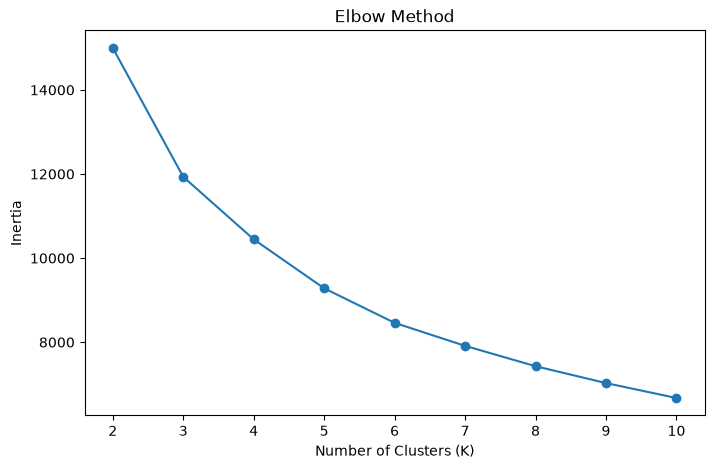

In [32]:
plt.figure(figsize=(8, 5))

plt.plot(range(2, 11), inertia, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [33]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

In [34]:
rfm.head()

,Recency,Frequency,Monetary,AvgOrderValue,TotalQuantity,UniqueProducts,Cluster
CustomerID,,,,,,,
12346.0,326,1,77183.60,77183.600000,74215,1,2
12347.0,2,7,4310.00,615.714286,2458,103,2
12348.0,75,4,1797.24,449.310000,2341,22,0
12349.0,19,1,1757.55,1757.550000,631,73,1
12350.0,310,1,334.40,334.400000,197,17,1


In [35]:
rfm["Cluster"].value_counts().sort_index()

Cluster
0    1252
1    1231
2     824
3    1031
Name: count, dtype: int64

In [36]:
cluster_summary = rfm.groupby("Cluster").mean()

cluster_summary

,Recency,Frequency,Monetary,AvgOrderValue,TotalQuantity,UniqueProducts
Cluster,,,,,,
0,35.861821,3.926518,1101.307109,303.783611,666.010383,66.319489
1,146.554833,1.543461,717.569816,490.997127,413.268075,32.270512
2,24.406553,12.411408,7830.239248,832.432508,4508.576456,158.660194
3,151.313288,1.444229,191.198661,143.224474,106.854510,12.899127


In [37]:
cluster_summary.round(2)

,Recency,Frequency,Monetary,AvgOrderValue,TotalQuantity,UniqueProducts
Cluster,,,,,,
0,35.86,3.93,1101.31,303.78,666.01,66.32
1,146.55,1.54,717.57,491.00,413.27,32.27
2,24.41,12.41,7830.24,832.43,4508.58,158.66
3,151.31,1.44,191.20,143.22,106.85,12.90


In [38]:
cluster_summary = rfm.groupby("Cluster")[[
    "Recency",
    "Frequency",
    "Monetary",
    "AvgOrderValue",
    "TotalQuantity",
    "UniqueProducts"
]].mean()

cluster_summary.round(2)

,Recency,Frequency,Monetary,AvgOrderValue,TotalQuantity,UniqueProducts
Cluster,,,,,,
0,35.86,3.93,1101.31,303.78,666.01,66.32
1,146.55,1.54,717.57,491.00,413.27,32.27
2,24.41,12.41,7830.24,832.43,4508.58,158.66
3,151.31,1.44,191.20,143.22,106.85,12.90


In [39]:
from sklearn.metrics import silhouette_score

silhouette = silhouette_score(rfm_scaled, rfm["Cluster"])

print("Silhouette Score:", round(silhouette, 4))

Silhouette Score: 0.2257


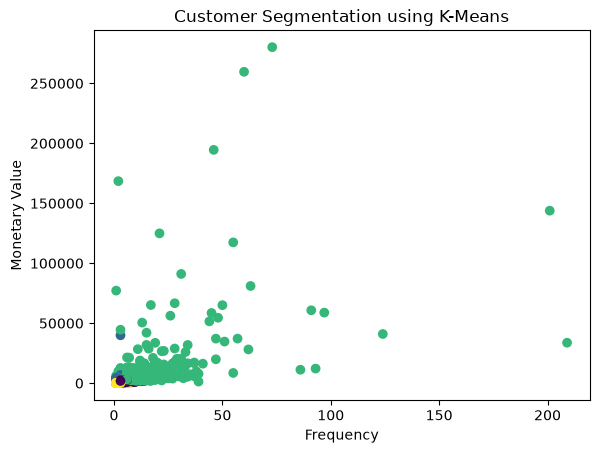

In [41]:
plt.scatter(
    rfm["Frequency"],
    rfm["Monetary"],
    c=rfm["Cluster"]
)

plt.xlabel("Frequency")
plt.ylabel("Monetary Value")
plt.title("Customer Segmentation using K-Means")
plt.show()

In [42]:
cluster_summary = rfm.groupby("Cluster")[[
    "Recency",
    "Frequency",
    "Monetary"
]].mean()

print(cluster_summary)

            Recency  Frequency     Monetary
Cluster                                    
0         35.861821   3.926518  1101.307109
1        146.554833   1.543461   717.569816
2         24.406553  12.411408  7830.239248
3        151.313288   1.444229   191.198661
